In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('DAVWorkshop_Survey.csv')

In [3]:
df.head()

,Timestamp,Name of your College,Age in years (please enter only a number/integer),Which district is your hometown located in?,PINCODE of your home address,Approx. Distance of your home from IIT Bhilai (in Kms). Enter only a number (floating point).,Approx. Time to reach IIT Bhilai from your hometown (in hours). Enter only a number (floating point),Did you appear in JEE?,"How comfortable are you with math of data science fundamentals: Linear algebra, Optimization, Statistics, Probability?",How comfortable are you with coding in Python?,What is your career goal?,What do you expect to learn from this workshop?,"What applications of data science are you most interested in? Give examples from your daily life, or things that impact you most...or where you can make an impact."
0,07-12-2025 16:22,Krishna Engineering College khamariya,2005,Durg,490006,10kms,30 min,Appeared but didn't Qualify,"Intermediate: can model some problems, solve s...","Intermediate: Some familiarity, made 1-2 projects",Become a software developer,To learn new things or technology,NaN
1,07-12-2025 16:23,Rungta college of engineering and technology,21,Saran,841410,1200km,32 hours,Appeared but didn't Qualify,"Intermediate: can model some problems, solve s...","Intermediate: Some familiarity, made 1-2 projects",Data analyst,I expected to gain a deeper understanding of c...,Finance sector or education
2,07-12-2025 16:27,"Rungta College of Engineering and Technology, ...",20,Ranchi,834005,604,13,Qualified JEE Mains,"Intermediate: can model some problems, solve s...","Intermediate: Some familiarity, made 1-2 proje...",My career goal is to become a skilled data sci...,I expect to gain hands-on experience in data w...,I?m interested in applying data science to hea...
3,07-12-2025 16:29,Krishna engineering college bhilai,22,Kanker,494337,3,0.15,Never appeared in JEE,"Intermediate: can model some problems, solve s...","Intermediate: Some familiarity, made 1-2 projects",Become a Ml or data engineer,Learn about data science,Power bi
4,07-12-2025 16:29,Krishna Engineering College,22,Durg,490023,5.1 kms,30 mins,Never appeared in JEE,Beginner: can't understand how to model data w...,"Intermediate: Some familiarity, made 1-2 projects",To Become a Data Scientist,I expect to gain practical insights into data ...,1.) Natural Language processing 2) Personalize...


In [4]:
df.isnull().sum()

Timestamp                                                                                                                                                               0
Name of your College                                                                                                                                                    1
Age in years (please enter only a number/integer)                                                                                                                       1
Which district is your hometown located in?                                                                                                                             2
PINCODE of your home address                                                                                                                                            4
Approx. Distance of your home from IIT Bhilai (in Kms). Enter only a number (floating point).                                                         

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 13 columns):
 #   Column                                                                                                                                                               Non-Null Count  Dtype 
---  ------                                                                                                                                                               --------------  ----- 
 0   Timestamp                                                                                                                                                            165 non-null    object
 1   Name of your College                                                                                                                                                 164 non-null    object
 2   Age in years (please enter only a number/integer)                                                                     

In [6]:
print(df.columns.tolist())


['Timestamp', 'Name of your College ', 'Age in years (please enter only a number/integer)', 'Which district is your hometown located in?', 'PINCODE of your home address', 'Approx. Distance of your home from IIT Bhilai (in Kms). Enter only a number (floating point).', 'Approx. Time to reach IIT Bhilai from your hometown (in hours). Enter only a number (floating point) ', 'Did you appear in JEE?', 'How comfortable are you with math of data science fundamentals: Linear algebra, Optimization, Statistics, Probability?', 'How comfortable are you with coding in Python?', 'What is your career goal?', 'What do you expect to learn from this workshop?', 'What applications of data science are you most interested in? Give examples from your daily life, or things that impact you most...or where you can make an impact.']


# Data Truncation

In [7]:
df.dropna(subset=["Age in years (please enter only a number/integer)",
                  "Approx. Distance of your home from IIT Bhilai (in Kms). Enter only a number (floating point).",
                  "Approx. Time to reach IIT Bhilai from your hometown (in hours). Enter only a number (floating point) "], inplace=True)

#Renaming of each columns


In [8]:
df.rename(columns={
    "Age in years (please enter only a number/integer)": "Age",
    "PINCODE of your home address": "Pincode",
    "Approx. Distance of your home from IIT Bhilai (in Kms). Enter only a number (floating point).": "Distance_km",
    "Approx. Time to reach IIT Bhilai from your hometown (in hours). Enter only a number (floating point) ": "Time_hr"
}, inplace=True)

# conversion of times to hours

In [9]:
df['Distance_km'] = df['Distance_km'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

# Similarly clean Time_hr (with custom function if needed)
import re

def time_to_hours(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower().strip()

    # Replace common misspellings
    x = x.replace('utes', 'min')
    x = x.replace('hrs', 'hour')
    x = x.replace('hr', 'hour')
    x = x.replace('mns', 'min')
    x = x.replace('mn', 'min')

    # Try direct conversion first
    try:
        return float(x)
    except:
        pass

    # Extract numeric value (digits and decimal)
    num_match = re.search(r'(\d+\.?\d*)', x)
    if not num_match:
        return np.nan
    val = float(num_match.group(1))

    # Determine unit
    if 'hour' in x:
        return val
    elif 'min' in x:
        return val / 60
    elif 's' in x or 'second' in x:
        return val / 3600
    else:
        # Unknown unit, fallback: assume hours if val < 10 else minutes (heuristic)
        if val < 10:
            return val
        else:
            return val / 60



df['Time_hr'] = df['Time_hr'].apply(time_to_hours)

In [10]:
df.rename(columns={"PINCODE of your home address": "Pincode"}, inplace=True)

# Imputation of missing values

In [11]:
# Impute missing PINCODE values with the most frequent PINCODE
df['Pincode'] = df['Pincode'].fillna(df['Pincode'].mode()[0])

# Ensure Distance_km and Time_hr columns are floats (should already be)
df['Distance_km'] = df['Distance_km'].astype(float)
df['Time_hr'] = df['Time_hr'].astype(float)

In [12]:
df['Distance_km']

0        10.0
1      1200.0
2       604.0
3         3.0
4         5.1
        ...  
159      44.0
160       5.2
161      60.0
163      15.0
164      50.0
Name: Distance_km, Length: 146, dtype: float64

In [13]:
df['Time_hr']

0       0.50
1      32.00
2      13.00
3       0.15
4       0.50
       ...  
159     1.30
160    25.00
161     2.00
163     0.50
164     2.00
Name: Time_hr, Length: 146, dtype: float64

In [14]:
df['Distance_km'] = df['Distance_km'].astype(float)
df['Time_hr'] = df['Time_hr'].astype(float)

# Fill missing values with mean
df['Distance_km'] = df['Distance_km'].fillna(df['Distance_km'].mean())
df['Time_hr'] = df['Time_hr'].fillna(df['Time_hr'].mean())


#Box PLot

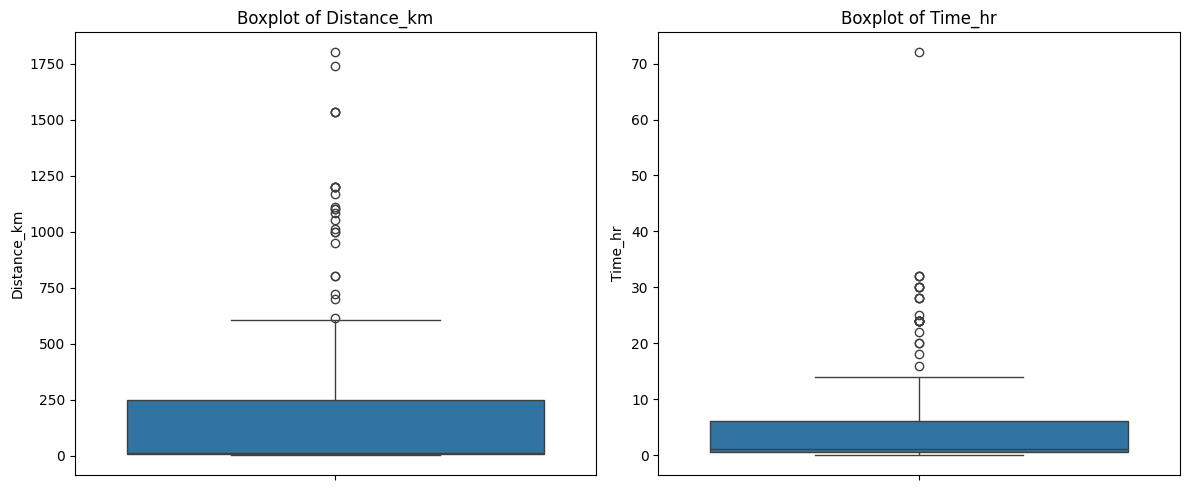

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Boxplot for Distance
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Distance_km'])
plt.title('Boxplot of Distance_km')

# Boxplot for Time
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Time_hr'])
plt.title('Boxplot of Time_hr')

plt.tight_layout()
plt.show()


Handling of Outlier using IQR

In [16]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

# Remove outliers from both columns
df = remove_outliers_iqr(df, 'Distance_km')
df = remove_outliers_iqr(df, 'Time_hr')


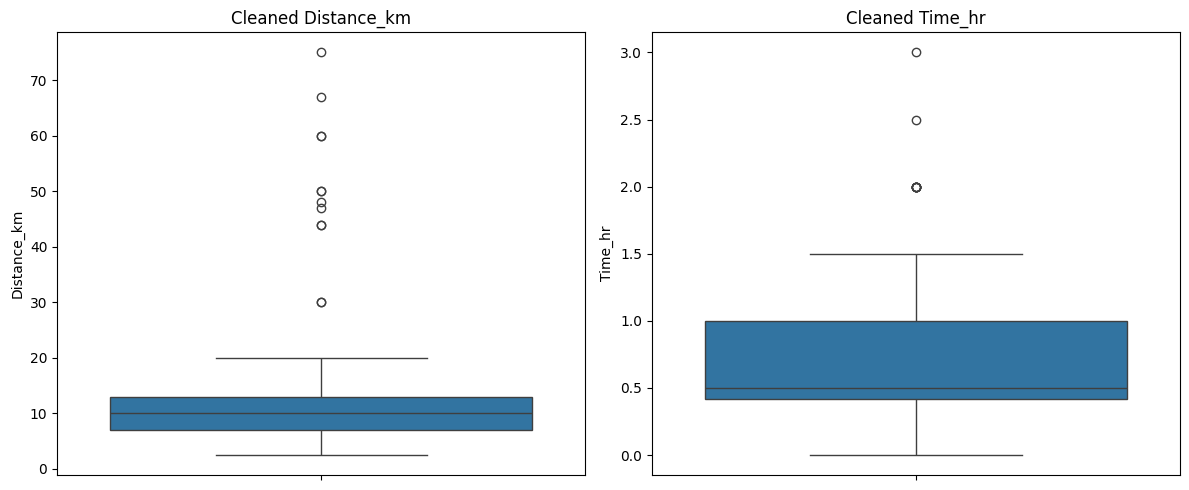

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Distance_km'])
plt.title('Cleaned Distance_km')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Time_hr'])
plt.title('Cleaned Time_hr')

plt.tight_layout()
plt.show()


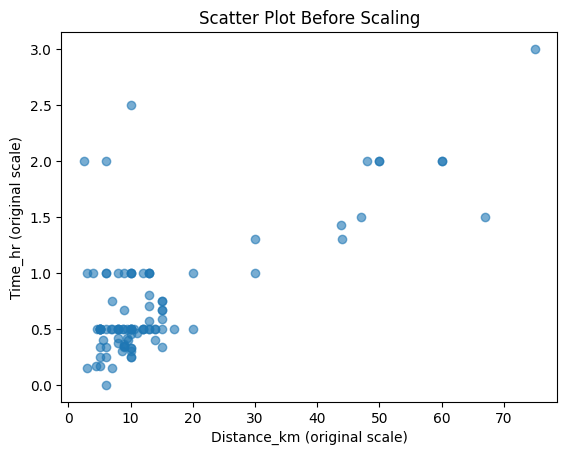

In [18]:
import matplotlib.pyplot as plt

plt.scatter(df['Distance_km'], df['Time_hr'], alpha=0.6)
plt.xlabel('Distance_km (original scale)')
plt.ylabel('Time_hr (original scale)')
plt.title('Scatter Plot Before Scaling')
plt.show()


# Standarization


In [19]:
df = df[['Distance_km', 'Time_hr']]

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit-transform both Distance and Time
scaled = scaler.fit_transform(df[['Distance_km', 'Time_hr']])
z_scores = np.abs(scaled)

# Set threshold (commonly 3)
threshold = 3

# Create mask to keep only non-outlier rows
mask = (z_scores < threshold).all(axis=1)


# Apply mask to original DataFrame
df_clean = df.iloc[mask].reset_index(drop=True)
df_clean.head()


,Distance_km,Time_hr
0,10.0,0.50
1,3.0,0.15
2,5.1,0.50
3,12.0,0.50
4,5.0,0.25


In [21]:
scaled_df = df_clean

In [22]:
scaled_df

,Distance_km,Time_hr
0,10.0,0.50
1,3.0,0.15
2,5.1,0.50
3,12.0,0.50
4,5.0,0.25
...,...,...
91,10.0,0.25
92,10.0,1.00
93,44.0,1.30
94,15.0,0.50


In [23]:
scaled_df.rename(columns={'Distance_km': 'Distance_km_scaled', 'Time_hr': 'Time_hr_scaled'}, inplace=True)


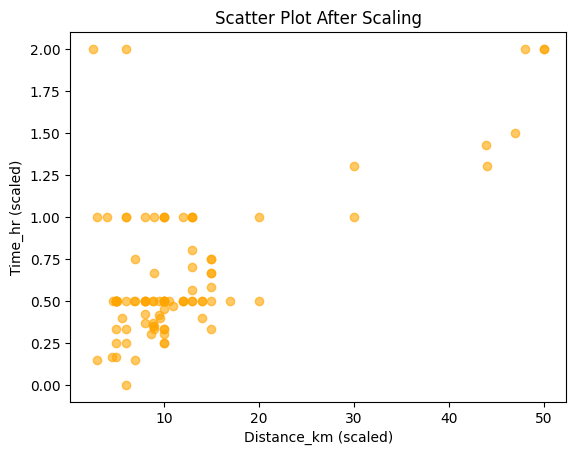

In [24]:
plt.scatter(scaled_df['Distance_km_scaled'], scaled_df['Time_hr_scaled'], alpha=0.6, color='orange')
plt.xlabel('Distance_km (scaled)')
plt.ylabel('Time_hr (scaled)')
plt.title('Scatter Plot After Scaling')
plt.show()


# Handling of Outlier using Standarization


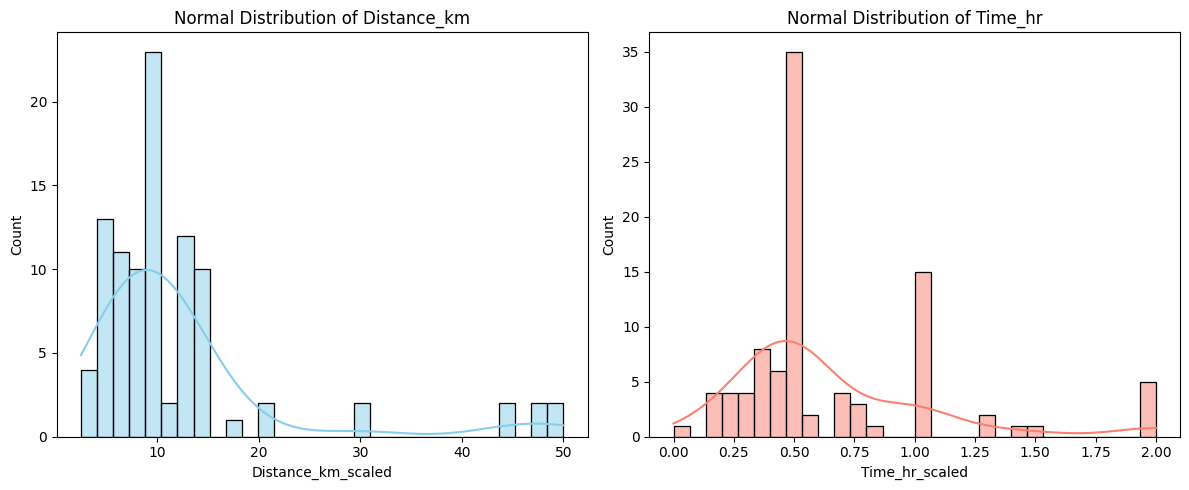

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Distribution of Distance_km
plt.subplot(1, 2, 1)
sns.histplot(scaled_df['Distance_km_scaled'], kde=True, bins=30, color='skyblue')
plt.title('Normal Distribution of Distance_km')

# Distribution of Time_hr
plt.subplot(1, 2, 2)
sns.histplot(scaled_df['Time_hr_scaled'], kde=True, bins=30, color='salmon')
plt.title('Normal Distribution of Time_hr')

plt.tight_layout()
plt.show()


In [26]:
scaled_df['Distance_km_scaled'].max()

50.0

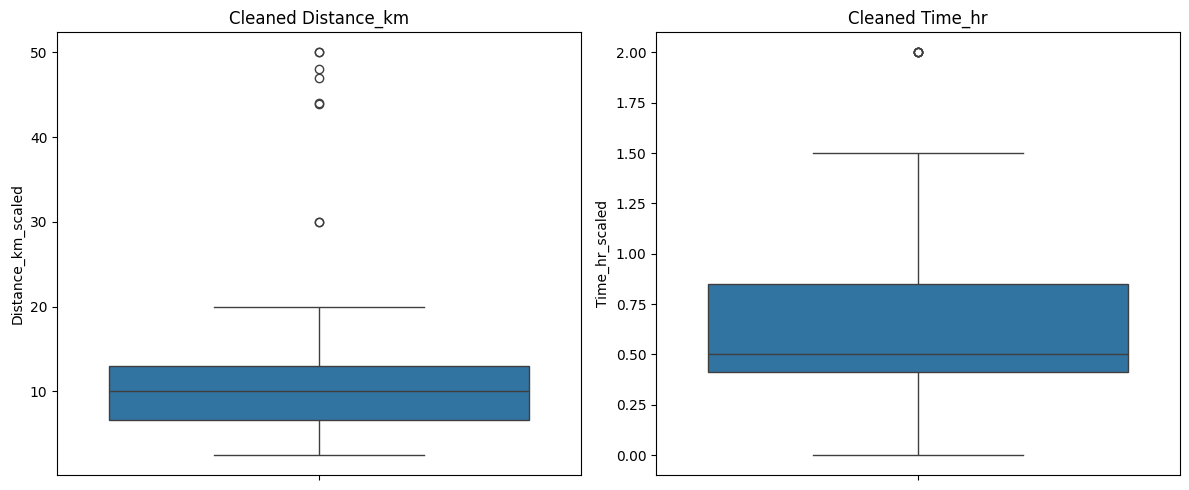

In [27]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=scaled_df['Distance_km_scaled'])
plt.title('Cleaned Distance_km')

plt.subplot(1, 2, 2)
sns.boxplot(y=scaled_df['Time_hr_scaled'])
plt.title('Cleaned Time_hr')

plt.tight_layout()
plt.show()


# Detecting of outliers using IQR

In [28]:
D_percentile25 = scaled_df['Distance_km_scaled'].quantile(0.25)
D_percentile75 = scaled_df['Distance_km_scaled'].quantile(0.75)

In [29]:
D_iqr = D_percentile75 - D_percentile25

In [30]:
T_percentile25 = scaled_df['Time_hr_scaled'].quantile(0.25)
T_percentile75 = scaled_df['Time_hr_scaled'].quantile(0.75)

In [31]:
T_iqr = T_percentile75 - T_percentile25

In [32]:
upper_limit_distance = D_percentile75 + 1.5 * D_iqr
lower_limit_distance = D_percentile25 - 1.5 * D_iqr

In [33]:
upper_limit_time = T_percentile75 + 1.5 *T_iqr
lower_limit_time = T_percentile25 - 1.5 *T_iqr

In [34]:
# Finding the outliers
scaled_df[(scaled_df['Time_hr_scaled'] > upper_limit_time) | (scaled_df['Time_hr_scaled'] < lower_limit_time)]

,Distance_km_scaled,Time_hr_scaled
6,48.0,2.0
57,50.0,2.0
78,2.5,2.0
88,6.0,2.0
95,50.0,2.0


In [35]:
# Finding the outliers
scaled_df[(scaled_df['Distance_km_scaled'] > upper_limit_distance) | (scaled_df['Distance_km_scaled'] < lower_limit_distance)]

,Distance_km_scaled,Time_hr_scaled
6,48.0,2.00
14,30.0,1.30
15,47.0,1.50
18,43.9,1.43
30,30.0,1.00
57,50.0,2.00
93,44.0,1.30
95,50.0,2.00


# Capping of Outlier

In [36]:
scaled_df['Distance_km_scaled'] = np.where(
    scaled_df['Distance_km_scaled']>upper_limit_distance,
    upper_limit_distance,
    np.where(
        scaled_df['Distance_km_scaled']<lower_limit_distance,
        lower_limit_distance,
        scaled_df['Distance_km_scaled']
    )
)

In [37]:
scaled_df['Time_hr_scaled'] = np.where(
    scaled_df['Time_hr_scaled']>upper_limit_time,
    upper_limit_time,
    np.where(
        scaled_df['Time_hr_scaled']<lower_limit_time,
        lower_limit_time,
        scaled_df['Time_hr_scaled']
    )
)

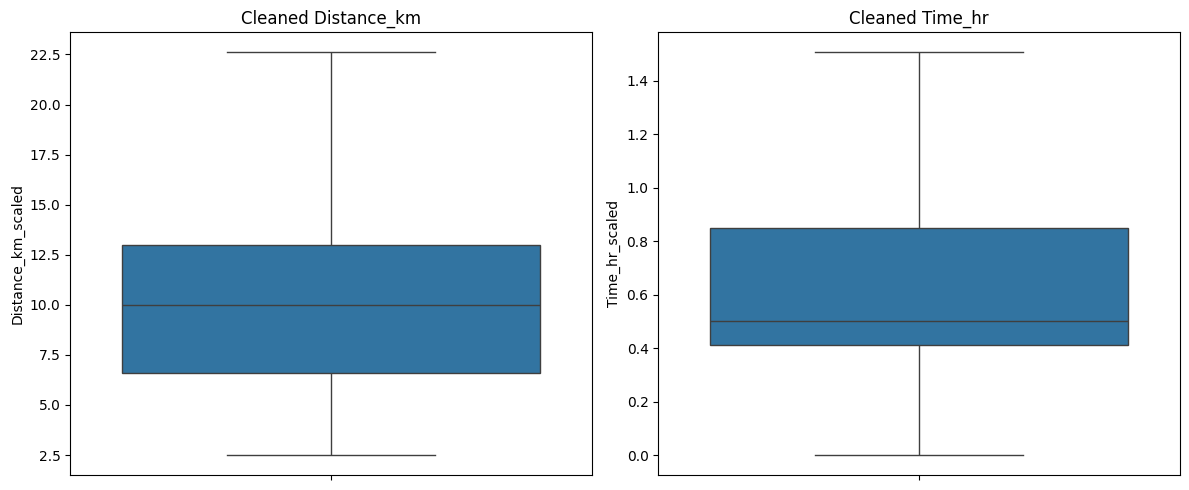

In [38]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=scaled_df['Distance_km_scaled'])
plt.title('Cleaned Distance_km')

plt.subplot(1, 2, 2)
sns.boxplot(y=scaled_df['Time_hr_scaled'])
plt.title('Cleaned Time_hr')

plt.tight_layout()
plt.show()


In [39]:
upper_limit_distance

22.6

In [40]:
scaled_df['Distance_km_scaled']>upper_limit_time

0     True
1     True
2     True
3     True
4     True
      ... 
91    True
92    True
93    True
94    True
95    True
Name: Distance_km_scaled, Length: 96, dtype: bool

In [41]:
# Finding the outliers
scaled_df[(scaled_df['Time_hr_scaled'] > upper_limit_time) | (scaled_df['Time_hr_scaled'] < lower_limit_time)]

,Distance_km_scaled,Time_hr_scaled


In [42]:
# Finding the outliers
scaled_df[(scaled_df['Distance_km_scaled'] > upper_limit_distance) | (scaled_df['Distance_km_scaled'] < lower_limit_distance)]

,Distance_km_scaled,Time_hr_scaled


In [43]:
from sklearn.model_selection import train_test_split
X = scaled_df[['Distance_km_scaled']]
y = scaled_df['Time_hr_scaled']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#Training

In [44]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
y_pred = model.predict(X_test)

#Evaluating

In [46]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_pred)


0.0624214426601619

In [47]:
np.sqrt(mean_squared_error(y_test,y_pred))

0.24984283591922724

Plotting after training

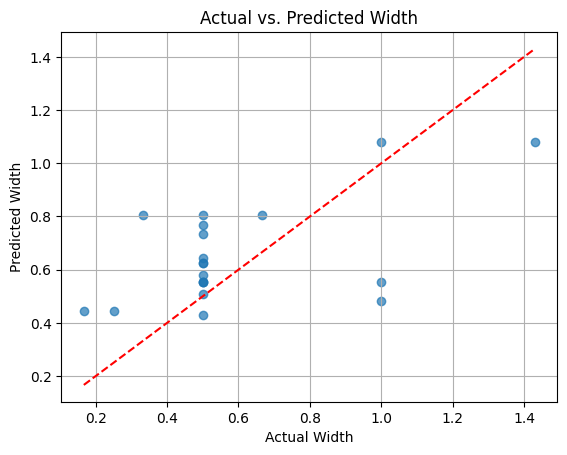

In [48]:
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Width')
plt.ylabel('Predicted Width')
plt.title('Actual vs. Predicted Width')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.grid(True)
plt.show()
